In [10]:
###################################################
######## Load all necessary packages ##############
###################################################



using Random, StatsBase, LinearAlgebra
using Plots, Statistics, DelimitedFiles, Colors, LaTeXStrings


# --- Precompute neighbors ---
function build_neighbors(genotypes, alleles_per_locus)
    neighbor_map = Dict{String, Vector{String}}()

    for g in genotypes
        neighbors = String[]
        g_arr = collect(g)

        for i in eachindex(g_arr)
            for allele in alleles_per_locus[i]
                if allele != g_arr[i]
                    new_g = copy(g_arr)
                    new_g[i] = allele
                    push!(neighbors, join(new_g))
                end
            end
        end

        neighbor_map[g] = neighbors
    end

    return neighbor_map
end

# Convert genotype → string
genotype_to_string(g) = join(g)

# Hamming distance
hamming(g1, g2) = sum(x != y for (x, y) in zip(g1, g2))


# --- Find peak of a genotype with memoization ---
function find_peak(g, landscape, neighbor_map, memo)
    # If already computed, return cached result
    if haskey(memo, g)
        return memo[g]
    end

    current = g

    while true
        neighbors = neighbor_map[current]

        # Find neighbor with maximum fitness
        best = current
        best_fit = landscape[current]

        for n in neighbors
            if landscape[n] > best_fit
                best = n
                best_fit = landscape[n]
            end
        end

        # If no strictly better neighbor → local peak
        if best == current
            memo[current] = current
            return current
        end

        # Move greedily to best neighbor
        current = best

        # Check memo again (path compression)
        if haskey(memo, current)
            memo[g] = memo[current]
            return memo[current]
        end
    end
end


# --- Generate NK landscape ---
function generate_NK_landscape(genotypes, alleles_per_locus, K,L)

    a = length(alleles_per_locus)

    # Choose K partners per locus (can include itself or not; here exclude)
    partners = [
    [mod1(i + j, L) for j in 1:(K-1)]
    for i in 1:L
    ]

    # Fitness tables
    tables = Dict{Int, Dict{String, Float64}}()
    for i in 1:L
        tables[i] = Dict{String, Float64}()
    end

    landscape = Dict{String, Float64}()

    for g in genotypes
        g_arr = collect(g)
        fitness = 0.0

        for i in 1:L
            # Build key: allele at i + alleles at partners
            key_chars = [g_arr[i]]
            for j in partners[i]
                push!(key_chars, g_arr[j])
            end
            key = join(key_chars)

            if !haskey(tables[i], key)
                tables[i][key] = randn()
            end

            fitness += tables[i][key]
        end

        landscape[g] = fitness
    end

    vals = collect(values(landscape))
    min_val = minimum(vals)
    max_val = maximum(vals)

    norm_landscape = Dict{typeof(first(keys(landscape))), Float64}()

    for (g, f) in landscape
        norm_landscape[g] = (f - min_val) / (max_val - min_val)
    end

    return norm_landscape
end

function generate_RMF(a, L, c)

    # Alleles
    alleles_per_locus = [ [Char('0' + i) for i in 0:a-1] for _ in 1:L ]

    # Genotypes
    genotypes = [join(g) for g in Iterators.product(alleles_per_locus...)]

    # Reference genotype (all zeros)
    ref = genotypes[1]
    ref_arr = collect(ref)

    # Landscape
    landscape = Dict{String, Float64}()

    for g in genotypes
        g_arr = collect(g)

        # Hamming distance
        d = sum(g_arr .!= ref_arr)

        # RMF fitness
        landscape[g] = (c* ( - d) +  randn())
    end

    vals = collect(values(landscape))
    min_val = minimum(vals)
    max_val = maximum(vals)

    norm_landscape = Dict{typeof(first(keys(landscape))), Float64}()

    for (g, f) in landscape
        norm_landscape[g] = (f - min_val) / (max_val - min_val)
    end

    return norm_landscape, genotypes
end

function generate_alternating_landscape(L, a; reference=nothing)
    
    genotypes = collect(Iterators.product(ntuple(_ -> 0:a-1, L)...))
    
    # Choose random reference genotype if not provided
    ref = isnothing(reference) ? rand(genotypes) : reference
    
    fitness_map = Dict{String, Float64}()
    
    for g in genotypes
        d = hamming(g, ref)
        
        # Alternating fitness: even distances high, odd distances low
        if iseven(d)
            fitness = 1.0 - 0.1*d + 0.01*randn()  # decreasing but high
        else
            fitness = 0.1 / (d+1)+ 0.01* randn()    # low fitness
        end
        
        # Ensure non-negative
        fitness = max(fitness, 0.0)
        
        fitness_map[genotype_to_string(g)] = fitness
    end
    
    # Normalize so max fitness = 1
    max_fit = maximum(values(fitness_map))
    for k in keys(fitness_map)
        fitness_map[k] /= max_fit
    end
    
    return fitness_map, genotype_to_string(ref)
end


function compute_random_adaptive_basins(a, L, land, c, K; N=1000, tol=1e-8)

    # Generate genotypes
    alleles_per_locus = [ [Char('0'+i) for i in 0:a-1] for _ in 1:L ]
    genotypes = [join(g) for g in Iterators.product(alleles_per_locus...)]

    # Generate landscape
    if land == "NK"
        landscape = generate_NK_landscape(genotypes, alleles_per_locus, K, L)
    elseif land == "hoc"
        landscape = Dict(g=>randn() for g in genotypes)
        vals = collect(values(landscape))
        min_val, max_val = minimum(vals), maximum(vals)
        for g in genotypes
            landscape[g] = (landscape[g]-min_val)/(max_val-min_val)
        end
    elseif land == "RMF"
        landscape, genotypes = generate_RMF(a,L,c)
    elseif land == "alt"
        landscape = generate_alternating_landscape(L,a)[1]
    else
        error("Invalid landscape type")
    end

    # Build neighbors
    neighbor_map = build_neighbors(genotypes, alleles_per_locus)

    # Compute neutral networks
    neutral_memo = Dict{String,String}()
    visited_global = Set{String}()

    for g in genotypes
        if g in visited_global
            continue
        end

        queue = [g]
        component = Set([g])
        while !isempty(queue)
            curr = popfirst!(queue)
            for n in neighbor_map[curr]
                if abs(landscape[n]-landscape[g])<tol && !(n in component)
                    push!(component,n)
                    push!(queue,n)
                end
            end
        end

        rep = sort(collect(component))[1]
        for node in component
            neutral_memo[node] = rep
        end
        union!(visited_global, component)
    end

    #  Simulate N random adaptive walks
    basin_counts = Dict{String, Int}()
    for _ in 1:N
        # pick a random starting genotype
        current = genotypes[rand(1:length(genotypes))]

        peak = neutral_memo[current]  # initialize peak

        while true
            # all members of current NC
            nc_rep = neutral_memo[current]
            nc_members = [x for x in keys(neutral_memo) if neutral_memo[x]==nc_rep]

            # neighbors outside NC that are higher
            higher_neighbors = String[]
            for n in nc_members
                for nb in neighbor_map[n]
                    if neutral_memo[nb]!=nc_rep && landscape[nb] > landscape[n] + tol
                        push!(higher_neighbors, nb)
                    end
                end
            end

            if isempty(higher_neighbors)
                # reached true peak
                peak = nc_rep
                break
            else
                # randomly move to one higher neighbor
                current = higher_neighbors[rand(1:length(higher_neighbors))]
            end
        end

        # increment basin count
        basin_counts[peak] = get(basin_counts, peak, 0) + 1
    end

    #  Fraction in global peak
    global_peak = findmax(landscape)[2]
    global_rep = neutral_memo[global_peak]
    fraction_peak = basin_counts[global_rep]/N

    return basin_counts, landscape, fraction_peak
end


function neighbors(g::String, alphabet::Vector{Char})
    L = length(g)
    result = String[]
    
    for i in 1:L
        for a in alphabet
            if a != g[i]
                newg = g[1:i-1] * string(a) * g[i+1:end]
                push!(result, newg)
            end
        end
    end
    
    return result
end

function adaptive_basin_size(fitness::Dict{String, Float64})

    alphabet = sort(collect(Set(vcat([collect(k) for k in keys(fitness)]...))))
    
    peak_fit, peak = findmax(fitness)

    # reverse graph
    reverse_graph = Dict{String, Vector{String}}()
    for g in keys(fitness)
        reverse_graph[g] = String[]
    end

    for g in keys(fitness)
        for n in neighbors(g, alphabet)
            if haskey(fitness, n) && fitness[n] > fitness[g]
                push!(reverse_graph[n], g)
            end
        end
    end

    # DFS
    visited = Set{String}()
    stack = [peak]

    while !isempty(stack)
        current = pop!(stack)
        if !(current in visited)
            push!(visited, current)
            append!(stack, reverse_graph[current])
        end
    end

    return length(visited), peak, peak_fit
end



# --- Compute N exactly ---
function compute_N_exact(a, L, land, c, K)

     basin_sizes, landscape = compute_random_adaptive_basins(a, L, land, c, K, N=5000)[1:2]

    global_basin = adaptive_basin_size(landscape)[1]/a^L

    total = a^L
    N_val = 0.0
    mean_F = 0.0

    for (peak, size) in basin_sizes
        P_reach = size / sum(values(basin_sizes))
        F_peak = landscape[peak]
        mean_F += F_peak
        N_val += P_reach * F_peak
    end

    return 1-N_val, basin_sizes, 1-mean_F/length(basin_sizes), length(basin_sizes), global_basin
end



compute_N_exact (generic function with 1 method)

In [11]:
#########################################
############ Input parameters ##############
L = 5; a=3 ### lenght of genotype and number of alleles

K = 2; c = 2; ### NK number of interacting partners and RMF slope
#########################################



#################################
######## Run code ##############
################################




landscapes = ["hoc",  "NK", "RMF", "alt"]

colors = Dict(
    "hoc" => RGB(0.9, 0.00, 0.00),
    "NK"  => RGB(0.90, 0.60, 0.0),
    "RMF" => RGB(0.0, 0.60, 0.50)
)

all_R = Float64[]
all_peaks = Float64[]
all_base_R = Float64[]
var_R = Float64[]
var_base_R = Float64[]
var_peaks = Float64[]
all_gb_sizes = Float64[]
var_gb_sizes = Float64[]

tot = 10
for land in landscapes
    println(land)
    i = 0

        Rs = Float64[]
        base_R = Float64[]
        tot_peaks = Float64[]
        gb_sizes = Float64[]

    
        for reps in 1:tot
            N_val, basins, mean_F, npeaks, gb = compute_N_exact(a, L, land, c,K)
            push!(Rs, N_val)
            push!(base_R, mean_F)
            push!(tot_peaks, npeaks)
            push!(gb_sizes, 1-gb) 
        end

        push!(all_peaks, mean(tot_peaks))
        push!(all_R, mean(Rs))
        push!(all_base_R, mean(base_R))
        push!(all_gb_sizes, mean(gb_sizes))

        push!(var_R, var(Rs))
        push!(var_base_R, var(base_R))
        push!(var_peaks, var(tot_peaks))
        push!(var_gb_sizes, var(gb_sizes))
    end


hoc
NK
RMF
alt


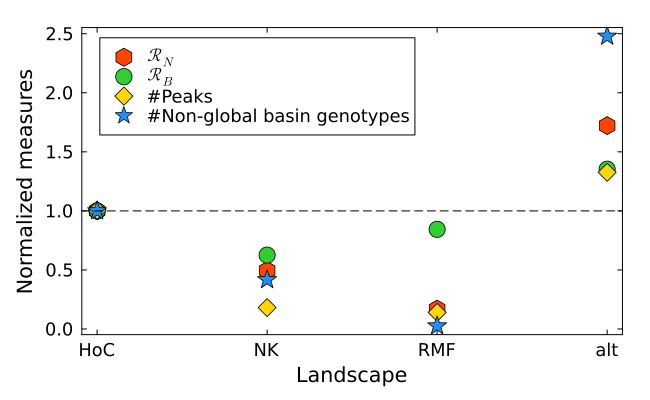

In [12]:
###################
### Plotting ######
###################

labels = ["HoC","NK","RMF","alt"]

R      = all_R      ./ all_R[1]
Rbase  = all_base_R ./ all_base_R[1]
peaks  = all_peaks .* ((a-1)*L+1) / a^L
gb     = all_gb_sizes ./ all_gb_sizes[1]

p = scatter(labels, R,
    marker = (:hexagon, 9),
    color = :orangered,
    label = L"\mathcal{R}_N",
    framestyle = :box,
    grid = false,
    legend = :topright
)

scatter!(labels, Rbase,
    marker = (:circle, 9),
    color = :limegreen,
    label = L"\mathcal{R}_B"
)

scatter!(labels, peaks,
    marker = (:diamond, 9),
    color = :gold,
    label = "#Peaks"
)

scatter!(labels, gb,
    marker = (:star5, 10),
    color = :dodgerblue,
    label = "#Non-global basin genotypes"
)

xlabel!("Landscape", guidefont=font(14))
ylabel!("Normalized measures", guidefont=font(14))

hline!([1.0], linestyle=:dash, color=:black, label=false)

plot!(
    tickfont = font(12),
    legendfont = font(12),
    size = (650, 400),
    margin = 5Plots.mm,
    legend=:topleft
)

display(p)